<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/19_Discovering_Kraichnan_orszag_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook for the MSE 510/420 course, Spring 2026
- Original notebook from: https://github.com/ShuaiGuo16/PINN_symbolic_regression
- Detailed walk-through is at: https://towardsdatascience.com/discovering-differential-equations-with-physics-informed-neural-networks-and-symbolic-regression-c28d279c0b4d
- Original paper is: https://arxiv.org/pdf/2307.08107.pdf
- Refactored by Sergei V. Kalinin

### Objective

In this notebook, we investigate combining PINN with symbolic regression to discover ODE systems. Our target ODE system can be written as follows:

\begin{align}
    \frac{du_1}{dt} &= e^{-t/10}u_2u_3 \\
    \frac{du_2}{dt} &= u_1u_3 \\
    \frac{du_3}{dt} &= -2u_1u_2 \\
\end{align}

with an initial condition of $u_1(0)=1, u_2(0)=0.8, u_3(0)=0.5$.

For our case study, we assume that we only know the right-hand side of the third equation to be a linear transformation of $u_1u_2$, and have no knowledge of the first two equations. Essentially, we can rewrite the ODE system as follows:

\begin{align}
    \frac{du_1}{dt} &= f_1(t, u_1, u_2, u_3) \\
    \frac{du_2}{dt} &= f_2(t, u_1, u_2, u_3) \\
    \frac{du_3}{dt} &= au_1u_2 + b \\
\end{align}

where $a, b$ are unknown coefficients and $f_1, f_2$ are the unknown functions. By using PINN and symbolic regression, we aim to calibrate the values of $a$ and $b$, as well as the functional forms of $f_1$ and $f_2$.

In [1]:
# !pip install keras==2.14.0 tensorflow==2.14.0

### 0. Import libraries

In [2]:
# Standard library
import time
from collections import defaultdict

# Scientific computing
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras

# Reproducibility
tf.random.set_seed(42)

### 1. Observational data generation

To begin with, we need to generate simulation data of the investigated ODE system, which will be used later for inverse calibration.

In [3]:
def simulate_odes(u_init, t_span, obs_num):
    """
    Simulate the ODE system and return observational data.

    Parameters
    ----------
    u_init : sequence of float
        Initial conditions for u1, u2, and u3.
    t_span : tuple[float, float]
        Start and end times for the simulation.
    obs_num : int
        Number of observation points.

    Returns
    -------
    np.ndarray
        Array of shape (obs_num, 4) with columns:
        [time, u1, u2, u3].
    """

    def ode_system(t, u):
        u1, u2, u3 = u
        du1_dt = np.exp(-t / 10.0) * u2 * u3
        du2_dt = u1 * u3
        du3_dt = -2.0 * u1 * u2
        return [du1_dt, du2_dt, du3_dt]

    t_start, t_end = t_span
    t_eval = np.linspace(t_start, t_end, obs_num)

    solution = solve_ivp(
        ode_system,
        t_span=t_span,
        y0=u_init,
        method="RK45",
        t_eval=t_eval,
    )

    u_obs = np.column_stack((solution.t, solution.y.T))
    return u_obs

In [4]:
# Simulation parameters
u_init = [1.0, 0.8, 0.5]
t_span = (0.0, 10.0)
obs_num = 1000

# Generate observations
u_obs = simulate_odes(u_init=u_init, t_span=t_span, obs_num=obs_num)

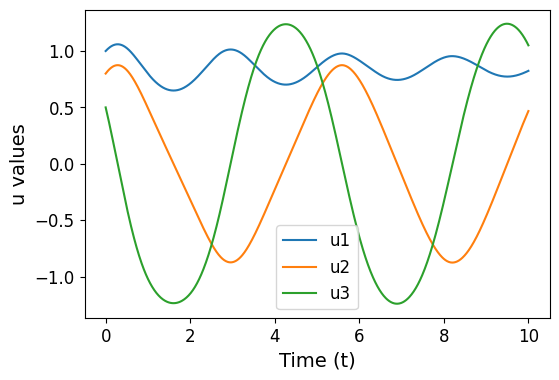

In [5]:
# Visualize simulation results
fig, ax = plt.subplots(figsize=(6, 4))

time_values = u_obs[:, 0]
state_labels = ("u1", "u2", "u3")

for idx, label in enumerate(state_labels, start=1):
    ax.plot(time_values, u_obs[:, idx], label=label)

ax.set_xlabel("Time (t)", fontsize=14)
ax.set_ylabel("u values", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, frameon=True)

fig.savefig("u_profile.png", bbox_inches="tight", transparent=True)
plt.show()

### 2. Organize dataset

In [6]:
# Batch sizes
data_batch_size = 100
ode_batch_size = 1000

# Collocation settings
n_collocation = 10_000

# Training data for supervised data loss
X_train_data = tf.convert_to_tensor(u_obs[:, :1], dtype=tf.float32)
y_train_data = tf.convert_to_tensor(u_obs[:, 1:], dtype=tf.float32)

train_ds_data = (
    tf.data.Dataset.from_tensor_slices((X_train_data, y_train_data))
    .shuffle(buffer_size=len(u_obs))
    .batch(data_batch_size)
)

# Training data for ODE residual loss
t_collocation = np.linspace(t_span[0], t_span[1], n_collocation, dtype=np.float32).reshape(-1, 1)
X_train_ode = tf.convert_to_tensor(t_collocation, dtype=tf.float32)

train_ds_ode = (
    tf.data.Dataset.from_tensor_slices(X_train_ode)
    .shuffle(buffer_size=10 * n_collocation)
    .batch(ode_batch_size)
)

# Test data
u_obs_test = simulate_odes(u_init=u_init, t_span=t_span, obs_num=5000)
X_test = u_obs_test[:, :1]
y_test = u_obs_test[:, 1:]

### 3. Physics-informed Neural Networks

#### Define a custom layer for hosting unknown parameters

In [7]:
class ParameterLayer(tf.keras.layers.Layer):
    def __init__(self, a, b, trainable=True, **kwargs):
        super().__init__(trainable=trainable, **kwargs)
        self._a_init = tf.convert_to_tensor(a, dtype=tf.float32)
        self._b_init = tf.convert_to_tensor(b, dtype=tf.float32)

    def build(self, input_shape):
        self.a = self.add_weight(
            name="a",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self._a_init),
            trainable=self.trainable,
        )
        self.b = self.add_weight(
            name="b",
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self._b_init),
            trainable=self.trainable,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "a": self._a_init.numpy().tolist(),
                "b": self._b_init.numpy().tolist(),
            }
        )
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

#### Define Physics-informed Neural Network

In [8]:
def build_mlp(inputs, hidden_units=50, num_hidden_layers=2, activation="tanh", output_units=1):
    """Build a simple multilayer perceptron."""
    x = inputs
    for _ in range(num_hidden_layers):
        x = tf.keras.layers.Dense(hidden_units, activation=activation)(x)
    return tf.keras.layers.Dense(output_units)(x)


def u_net(input_layer, hidden_units=50, num_hidden_layers=2, activation="tanh"):
    """Network for predicting u = [u1, u2, u3]."""
    return build_mlp(
        inputs=input_layer,
        hidden_units=hidden_units,
        num_hidden_layers=num_hidden_layers,
        activation=activation,
        output_units=3,
    )


def f_net(input_layers, a_init=None, b_init=None, hidden_units=50, num_hidden_layers=2, activation="tanh"):
    """Network for predicting f and storing trainable parameters a and b."""
    x = tf.keras.layers.Concatenate()(input_layers)
    x = build_mlp(
        inputs=x,
        hidden_units=hidden_units,
        num_hidden_layers=num_hidden_layers,
        activation=activation,
        output_units=2,
    )
    return ParameterLayer(a=a_init, b=b_init)(x)


def create_pinn(a_init=None, b_init=None, verbose=False):
    """
    Create a physics-informed neural network.

    Parameters
    ----------
    a_init : float or array-like, optional
        Initial value for parameter a.
    b_init : float or array-like, optional
        Initial value for parameter b.
    verbose : bool, optional
        Whether to print the model summary.

    Returns
    -------
    tf.keras.Model
        PINN model with outputs [u, f].
    """
    t_input = tf.keras.Input(shape=(1,), name="time")

    u_output = u_net(t_input)
    f_output = f_net([t_input, u_output], a_init=a_init, b_init=b_init)

    model = tf.keras.Model(inputs=t_input, outputs=[u_output, f_output], name="pinn")

    if verbose:
        model.summary()

    return model

#### ODE loss

In [9]:
@tf.function
def compute_ode_residual(t, model):
    """
    Compute the residuals of the governing ODE system.

    Parameters
    ----------
    t : tf.Tensor
        Temporal coordinates with shape (batch_size, 1).
    model : tf.keras.Model
        PINN model returning [u, f].

    Returns
    -------
    tf.Tensor
        ODE residual tensor with shape (batch_size, 3).
    """
    parameter_layer = model.layers[-1]
    a = parameter_layer.a
    b = parameter_layer.b

    with tf.GradientTape() as tape:
        tape.watch(t)
        u_pred, f_pred = model(t, training=True)

    du_dt = tape.batch_jacobian(u_pred, t)[:, :, 0]

    du1_dt = du_dt[:, 0:1]
    du2_dt = du_dt[:, 1:2]
    du3_dt = du_dt[:, 2:3]

    u1 = u_pred[:, 0:1]
    u2 = u_pred[:, 1:2]

    residual_1 = du1_dt - f_pred[:, 0:1]
    residual_2 = du2_dt - f_pred[:, 1:2]
    residual_3 = du3_dt - (a * u1 * u2 + b)

    return tf.concat([residual_1, residual_2, residual_3], axis=1)

#### Gradient descent step

In [11]:
@tf.function
def train_step(X_ode, X_data, y_data, ic_weight, ode_weight, data_weight, model):
    initial_condition_target = tf.constant([[1.0, 0.8, 0.5]], dtype=tf.float32)
    initial_time = tf.zeros((1, 1), dtype=tf.float32)

    with tf.GradientTape() as tape:
        y_pred_ic, _ = model(initial_time, training=True)
        ode_residual = compute_ode_residual(t=X_ode, model=model)
        y_pred_data, _ = model(X_data, training=True)

        ic_loss = tf.reduce_mean(tf.square(initial_condition_target - y_pred_ic))
        ode_loss = tf.reduce_mean(tf.square(ode_residual))
        data_loss = tf.reduce_mean(tf.square(y_data - y_pred_data))

        total_loss = (
            ic_weight * ic_loss
            + ode_weight * ode_loss
            + data_weight * data_loss
        )

    gradients = tape.gradient(total_loss, model.trainable_variables)
    return ode_loss, ic_loss, data_loss, total_loss, gradients

#### Define loss tracking class

In [12]:
class LossTracker:
    def __init__(self):
        self.total_loss_metric = keras.metrics.Mean(name="total_loss")
        self.ic_loss_metric = keras.metrics.Mean(name="ic_loss")
        self.ode_loss_metric = keras.metrics.Mean(name="ode_loss")
        self.data_loss_metric = keras.metrics.Mean(name="data_loss")
        self.loss_history = defaultdict(list)

    def update(self, total_loss, ic_loss, ode_loss, data_loss):
        self.total_loss_metric.update_state(total_loss)
        self.ic_loss_metric.update_state(ic_loss)
        self.ode_loss_metric.update_state(ode_loss)
        self.data_loss_metric.update_state(data_loss)

    def reset(self):
        self.total_loss_metric.reset_state()
        self.ic_loss_metric.reset_state()
        self.ode_loss_metric.reset_state()
        self.data_loss_metric.reset_state()

    def print_losses(self):
        print(
            f"IC={self.ic_loss_metric.result().numpy():.4e}, "
            f"ODE={self.ode_loss_metric.result().numpy():.4e}, "
            f"data={self.data_loss_metric.result().numpy():.4e}, "
            f"total_loss={self.total_loss_metric.result().numpy():.4e}"
        )

    def record_history(self):
        self.loss_history["total_loss"].append(self.total_loss_metric.result().numpy())
        self.loss_history["IC_loss"].append(self.ic_loss_metric.result().numpy())
        self.loss_history["ODE_loss"].append(self.ode_loss_metric.result().numpy())
        self.loss_history["data_loss"].append(self.data_loss_metric.result().numpy())

#### Define callback

In [13]:
class ParameterPrinter(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        parameter_layer = self.model.layers[-1]
        a_value = float(parameter_layer.a.numpy().squeeze())
        b_value = float(parameter_layer.b.numpy().squeeze())
        print(f"\na: {a_value:.6f}, b: {b_value:.6f}")

#### Training

In [14]:
# Training configuration
n_epochs = 1000

ic_weight = tf.constant(1.0, dtype=tf.float32)
ode_weight = tf.constant(1.0, dtype=tf.float32)
data_weight = tf.constant(1.0, dtype=tf.float32)

loss_tracker = LossTracker()
val_loss_hist = []
a_history, b_history = [], []

# Initial values for unknown parameters
a_init = -1.0
b_init = 1.0

# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=2e-2)

# Validation inputs
validation_times = tf.reshape(tf.linspace(t_span[0], t_span[1], 1000), (-1, 1))
initial_time = tf.zeros((1, 1), dtype=tf.float32)
initial_condition_target = tf.constant([[1.0, 0.8, 0.5]], dtype=tf.float32)

with tf.device("/CPU:0"):
    # Instantiate and compile the PINN model
    pinn = create_pinn(a_init=a_init, b_init=b_init)
    pinn.compile(optimizer=optimizer)

    # Configure callbacks
    callback_objects = [
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=100),
        keras.callbacks.ModelCheckpoint(
            filepath="PINN_model.h5",
            monitor="val_loss",
            save_best_only=True,
        ),
        ParameterPrinter(),
    ]
    callbacks = keras.callbacks.CallbackList(
        callback_objects,
        add_history=False,
        model=pinn,
    )

    callbacks.on_train_begin()

    # Training loop
    for epoch in range(1, n_epochs + 1):
        print(f"Epoch {epoch}:")
        callbacks.on_epoch_begin(epoch)

        for X_ode_batch, (X_data_batch, y_data_batch) in zip(train_ds_ode, train_ds_data):
            ode_loss, ic_loss, data_loss, total_loss, gradients = train_step(
                X_ode=X_ode_batch,
                X_data=X_data_batch,
                y_data=y_data_batch,
                ic_weight=ic_weight,
                ode_weight=ode_weight,
                data_weight=data_weight,
                model=pinn,
            )

            pinn.optimizer.apply_gradients(zip(gradients, pinn.trainable_variables))
            loss_tracker.update(total_loss, ic_loss, ode_loss, data_loss)

        # Epoch loss summary
        loss_tracker.record_history()
        loss_tracker.print_losses()
        loss_tracker.reset()

        # Record parameter values
        parameter_layer = pinn.layers[-1]
        a_history.append(parameter_layer.a.numpy())
        b_history.append(parameter_layer.b.numpy())

        # Validation
        val_residual = compute_ode_residual(validation_times, pinn)
        val_ode_loss = tf.cast(tf.reduce_mean(tf.square(val_residual)), tf.float32)

        val_pred_init, _ = pinn(initial_time, training=False)
        val_ic_loss = tf.reduce_mean(tf.square(val_pred_init - initial_condition_target))

        current_lr = tf.keras.backend.get_value(pinn.optimizer.learning_rate)
        print(
            f"val_IC: {val_ic_loss.numpy():.4e}, "
            f"val_ODE: {val_ode_loss.numpy():.4e}, "
            f"lr: {current_lr:.2e}"
        )

        val_loss = val_ic_loss + val_ode_loss
        callbacks.on_epoch_end(epoch, logs={"val_loss": float(val_loss.numpy())})
        val_loss_hist.append(val_loss)

        # Test set evaluation
        pred_test, _ = pinn.predict(X_test, batch_size=12800, verbose=0)
        test_rmse = mean_squared_error(y_test.flatten(), pred_test.flatten())
        print(f"RMSE: {test_rmse:.6f}")

        # Rebuild shuffled datasets for next epoch
        train_ds_data = (
            tf.data.Dataset.from_tensor_slices((X_train_data, y_train_data))
            .shuffle(buffer_size=10_000)
            .batch(data_batch_size)
        )

        train_ds_ode = (
            tf.data.Dataset.from_tensor_slices(X_train_ode)
            .shuffle(buffer_size=10 * n_collocation)
            .batch(ode_batch_size)
        )

    callbacks.on_train_end()

Epoch 1:


IC=2.4360e-01, ODE=7.8403e-01, data=1.6060e+00, total_loss=2.6337e+00
val_IC: 2.6539e-02, val_ODE: 3.1202e-01, lr: 2.00e-02

a: -0.887153, b: 0.875354
RMSE: 0.562888
Epoch 2:


IC=3.5090e-02, ODE=1.8668e-01, data=6.2526e-01, total_loss=8.4703e-01
val_IC: 1.1366e-02, val_ODE: 6.2651e-02, lr: 2.00e-02

a: -0.850620, b: 0.729231
RMSE: 0.542783
Epoch 3:


IC=3.2148e-02, ODE=1.3155e-01, data=4.3558e-01, total_loss=5.9928e-01
val_IC: 1.7142e-02, val_ODE: 3.0400e-02, lr: 2.00e-02

a: -0.847571, b: 0.591578
RMSE: 0.480697
Epoch 4:
IC=1.4348e-02, ODE=4.7924e-02, data=4.2239e-01, total_loss=4.8466e-01
val_IC: 9.6488e-03, val_ODE: 6.8148e-02, lr: 2.00e-02

a: -0.861335, b: 0.469630
RMSE: 0.376185
Epoch 5:


IC=3.5222e-03, ODE=3.2078e-02, data=3.8118e-01, total_loss=4.1678e-01
val_IC: 1.2844e-03, val_ODE: 2.6757e-02, lr: 2.00e-02

a: -0.880339, b: 0.352976
RMSE: 0.372807
Epoch 6:


...

IC=1.4957e-07, ODE=2.0396e-05, data=9.1135e-06, total_loss=2.9659e-05
val_IC: 1.0413e-07, val_ODE: 2.0030e-05, lr: 3.12e-04

a: -1.998616, b: 0.000021
RMSE: 0.000009
Epoch 968:
IC=1.8087e-07, ODE=1.9907e-05, data=9.2845e-06, total_loss=2.9373e-05
val_IC: 1.4419e-07, val_ODE: 2.0369e-05, lr: 3.12e-04

a: -1.998620, b: 0.000041
RMSE: 0.000009
Epoch 969:
IC=1.4105e-07, ODE=1.9771e-05, data=9.8439e-06, total_loss=2.9756e-05
val_IC: 5.5341e-08, val_ODE: 2.0655e-05, lr: 3.12e-04

a: -1.998601, b: -0.000022
RMSE: 0.000011
Epoch 970:
IC=7.5934e-08, ODE=2.0203e-05, data=9.3286e-06, total_loss=2.9607e-05
val_IC: 1.0332e-07, val_ODE: 2.0130e-05, lr: 1.56e-04

a: -1.998600, b: -0.000024
RMSE: 0.000009
Epoch 971:


IC=7.2579e-08, ODE=1.9666e-05, data=8.8333e-06, total_loss=2.8572e-05
val_IC: 2.8901e-08, val_ODE: 1.9744e-05, lr: 1.56e-04

a: -1.998608, b: -0.000011
RMSE: 0.000009
Epoch 972:
IC=6.6511e-08, ODE=1.9458e-05, data=8.8829e-06, total_loss=2.8408e-05
val_IC: 7.9592e-08, val_ODE: 2.0184e-05, lr: 1.56e-04

a: -1.998608, b: -0.000026
RMSE: 0.000009
Epoch 973:
IC=3.3866e-08, ODE=1.9411e-05, data=9.0749e-06, total_loss=2.8520e-05
val_IC: 1.1125e-08, val_ODE: 1.9945e-05, lr: 1.56e-04

a: -1.998620, b: -0.000006
RMSE: 0.000008
Epoch 974:


IC=1.7665e-08, ODE=1.9533e-05, data=8.6358e-06, total_loss=2.8187e-05
val_IC: 4.3148e-08, val_ODE: 1.9654e-05, lr: 1.56e-04

a: -1.998618, b: 0.000000
RMSE: 0.000009
Epoch 975:
IC=2.0147e-08, ODE=1.9355e-05, data=8.6684e-06, total_loss=2.8043e-05
val_IC: 2.1328e-09, val_ODE: 1.9929e-05, lr: 1.56e-04

a: -1.998609, b: -0.000000
RMSE: 0.000009
Epoch 976:
IC=1.9833e-08, ODE=1.9406e-05, data=8.6821e-06, total_loss=2.8108e-05
val_IC: 1.2299e-08, val_ODE: 1.9714e-05, lr: 1.56e-04

a: -1.998620, b: 0.000007
RMSE: 0.000009
Epoch 977:
IC=1.3414e-08, ODE=1.9380e-05, data=8.5333e-06, total_loss=2.7927e-05
val_IC: 7.0454e-09, val_ODE: 1.9735e-05, lr: 1.56e-04

a: -1.998617, b: 0.000020
RMSE: 0.000009
Epoch 978:
IC=9.6463e-09, ODE=1.9365e-05, data=8.7706e-06, total_loss=2.8146e-05
val_IC: 1.5560e-08, val_ODE: 1.9702e-05, lr: 1.56e-04

a: -1.998619, b: 0.000035
RMSE: 0.000009
Epoch 979:
IC=1.9869e-08, ODE=1.9286e-05, data=8.6922e-06, total_loss=2.7998e-05
val_IC: 2.5768e-08, val_ODE: 1.9823e-05, lr:

IC=2.1059e-08, ODE=1.9339e-05, data=8.7140e-06, total_loss=2.8074e-05
val_IC: 5.6483e-09, val_ODE: 1.9691e-05, lr: 1.56e-04

a: -1.998627, b: 0.000033
RMSE: 0.000008
Epoch 981:
IC=3.0305e-08, ODE=1.9367e-05, data=8.6545e-06, total_loss=2.8052e-05
val_IC: 6.8354e-08, val_ODE: 1.9900e-05, lr: 1.56e-04

a: -1.998623, b: 0.000044
RMSE: 0.000009
Epoch 982:
IC=5.1499e-08, ODE=1.9434e-05, data=8.8121e-06, total_loss=2.8297e-05
val_IC: 6.9147e-08, val_ODE: 1.9782e-05, lr: 1.56e-04

a: -1.998613, b: 0.000033
RMSE: 0.000009
Epoch 983:
IC=3.6477e-08, ODE=1.9427e-05, data=8.8275e-06, total_loss=2.8291e-05
val_IC: 2.6171e-08, val_ODE: 2.0178e-05, lr: 1.56e-04

a: -1.998608, b: 0.000022
RMSE: 0.000009
Epoch 984:
IC=3.1184e-08, ODE=1.9625e-05, data=8.5949e-06, total_loss=2.8252e-05
val_IC: 8.2696e-09, val_ODE: 1.9959e-05, lr: 1.56e-04

a: -1.998602, b: 0.000021
RMSE: 0.000009
Epoch 985:
IC=3.6934e-08, ODE=1.9461e-05, data=8.8856e-06, total_loss=2.8384e-05
val_IC: 2.1944e-08, val_ODE: 2.0088e-05, lr: 

IC=2.4421e-08, ODE=1.9382e-05, data=8.7414e-06, total_loss=2.8148e-05
val_IC: 3.9767e-08, val_ODE: 1.9567e-05, lr: 1.56e-04

a: -1.998620, b: 0.000017
RMSE: 0.000009
Epoch 994:
IC=3.8267e-08, ODE=1.9212e-05, data=8.7143e-06, total_loss=2.7964e-05
val_IC: 6.7624e-08, val_ODE: 2.0024e-05, lr: 1.56e-04

a: -1.998614, b: 0.000025
RMSE: 0.000009
Epoch 995:
IC=4.3243e-08, ODE=1.9425e-05, data=8.6704e-06, total_loss=2.8139e-05
val_IC: 1.7966e-08, val_ODE: 1.9651e-05, lr: 1.56e-04

a: -1.998625, b: 0.000037
RMSE: 0.000008
Epoch 996:
IC=3.4877e-08, ODE=1.9294e-05, data=8.6378e-06, total_loss=2.7967e-05
val_IC: 1.3182e-08, val_ODE: 2.0331e-05, lr: 1.56e-04

a: -1.998617, b: 0.000019
RMSE: 0.000009
Epoch 997:
IC=5.0724e-08, ODE=1.9679e-05, data=8.7849e-06, total_loss=2.8514e-05
val_IC: 4.2109e-08, val_ODE: 2.0202e-05, lr: 1.56e-04

a: -1.998629, b: 0.000036
RMSE: 0.000009
Epoch 998:
IC=6.9262e-08, ODE=1.9600e-05, data=8.8222e-06, total_loss=2.8492e-05
val_IC: 6.2733e-08, val_ODE: 1.9876e-05, lr: 

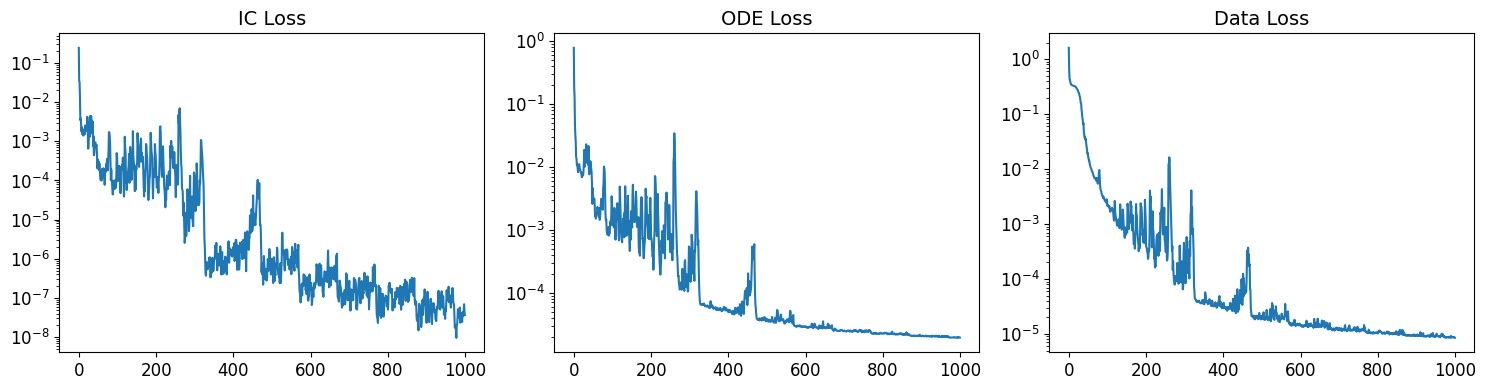

In [15]:
# Training history
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

history = loss_tracker.loss_history
loss_specs = [
    ("IC_loss", "IC Loss"),
    ("ODE_loss", "ODE Loss"),
    ("data_loss", "Data Loss"),
]

for ax, (key, title) in zip(axes, loss_specs):
    ax.plot(history[key])
    ax.set_title(title, fontsize=14)
    ax.set_yscale("log")
    ax.tick_params(axis="both", which="major", labelsize=12)

plt.tight_layout()
plt.show()

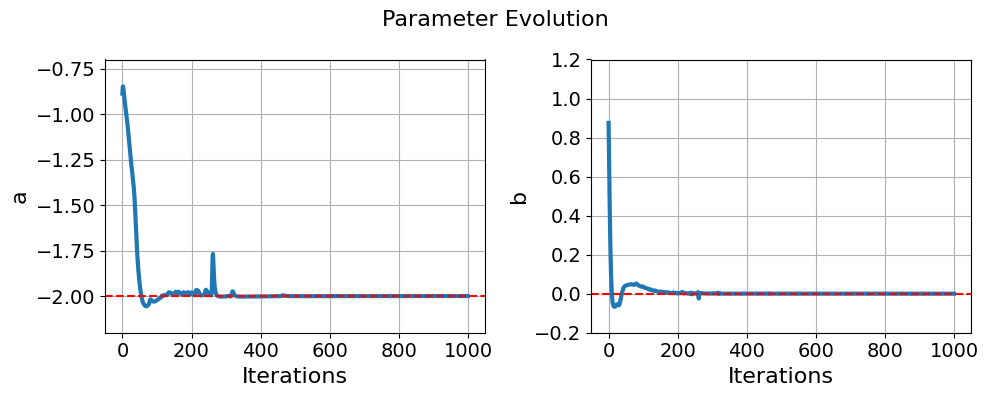

In [16]:
# Parameter history
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

a_values = np.asarray(a_history).squeeze()
b_values = np.asarray(b_history).squeeze()

parameter_specs = [
    (axes[0], a_values, "a", (-2.2, -0.7), -2.0),
    (axes[1], b_values, "b", (-0.2, 1.2), 0.0),
]

for ax, values, label, y_limits, reference_value in parameter_specs:
    ax.plot(values, lw=3)
    ax.set_ylabel(label, fontsize=16)
    ax.set_xlabel("Iterations", fontsize=16)
    ax.set_ylim(y_limits)
    ax.axhline(y=reference_value, color="r", linestyle="--")
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(True)

fig.suptitle("Parameter Evolution", fontsize=16)
plt.tight_layout()
plt.show()

#### Collect input/output of f-NN

In [17]:
time_grid = np.linspace(t_span[0], t_span[1], 10_000, dtype=np.float32).reshape(-1, 1)

with tf.device("/CPU:0"):
    u_pred, f_pred = pinn.predict(time_grid, batch_size=12_800, verbose=0)

results_df = pd.DataFrame(
    {
        "t": time_grid.ravel(),
        "u1": u_pred[:, 0],
        "u2": u_pred[:, 1],
        "u3": u_pred[:, 2],
        "f1": f_pred[:, 0],
        "f2": f_pred[:, 1],
    }
)
results_df.to_csv("f_NN_IO.csv", index=False)

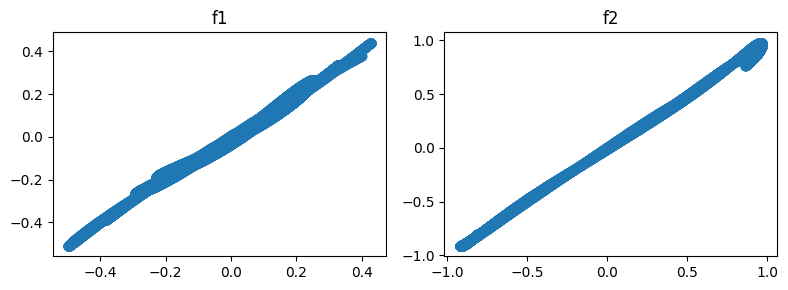

In [18]:
# Sanity check
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

f1_reference = np.exp(-results_df["t"].to_numpy() / 10.0) * results_df["u2"].to_numpy() * results_df["u3"].to_numpy()
f2_reference = results_df["u1"].to_numpy() * results_df["u3"].to_numpy()

plot_specs = [
    (axes[0], f1_reference, results_df["f1"].to_numpy(), "f1"),
    (axes[1], f2_reference, results_df["f2"].to_numpy(), "f2"),
]

for ax, x_values, y_values, title in plot_specs:
    ax.scatter(x_values, y_values)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### Assess accuracy: u prediction

In [19]:
# Generate predictions on a dense time grid
time_grid = np.linspace(t_span[0], t_span[1], 5000, dtype=np.float32).reshape(-1, 1)

with tf.device("/CPU:0"):
    pred_u, pred_f = pinn.predict(time_grid, batch_size=12_800, verbose=0)

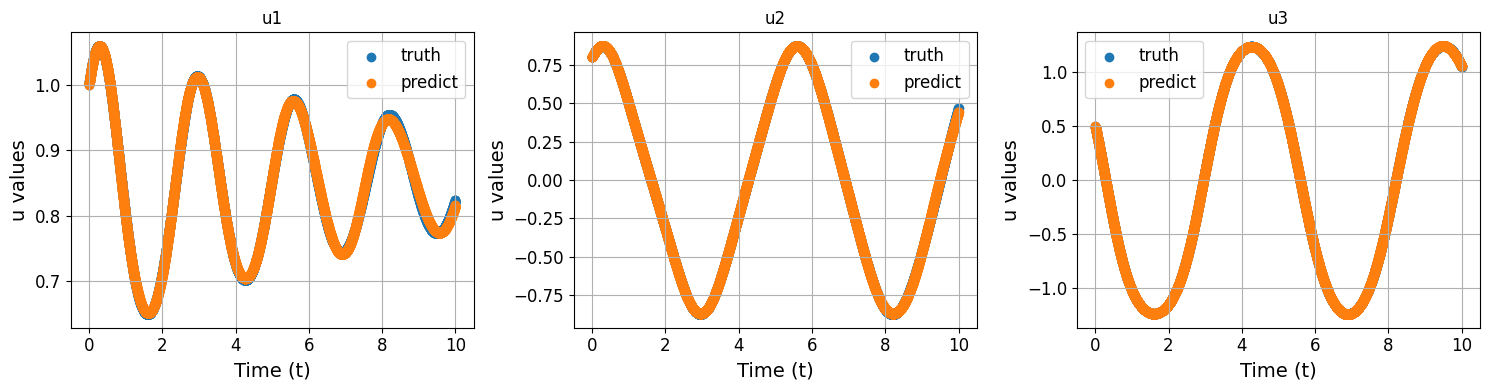

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(time_grid.flatten(), y_test[:, 0], label='truth')
ax[0].scatter(time_grid.flatten(), pred_u[:, 0], label='predict')
ax[0].set_title('u1')
ax[1].scatter(time_grid.flatten(), y_test[:, 1], label='truth')
ax[1].scatter(time_grid.flatten(), pred_u[:, 1], label='predict')
ax[1].set_title('u2')
ax[2].scatter(time_grid.flatten(), y_test[:, 2], label='truth')
ax[2].scatter(time_grid.flatten(), pred_u[:, 2], label='predict')
ax[2].set_title('u3')

for axs in ax:
    axs.set_xlabel('Time (t)', fontsize=14)
    axs.set_ylabel('u values', fontsize=14)
    axs.tick_params(axis='both', which='major', labelsize=12)
    axs.legend(fontsize=12, frameon=True)
    axs.grid(True)

plt.tight_layout()

#### Access accuracy: f prediction

In [21]:
# Compute time derivatives of the predicted state variables
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_test_tensor)
    u_pred, f_pred = pinn(X_test_tensor, training=False)

du_dt = tape.batch_jacobian(u_pred, X_test_tensor)[:, :, 0]

du1_dt = du_dt[:, 0:1]
du2_dt = du_dt[:, 1:2]
du3_dt = du_dt[:, 2:3]

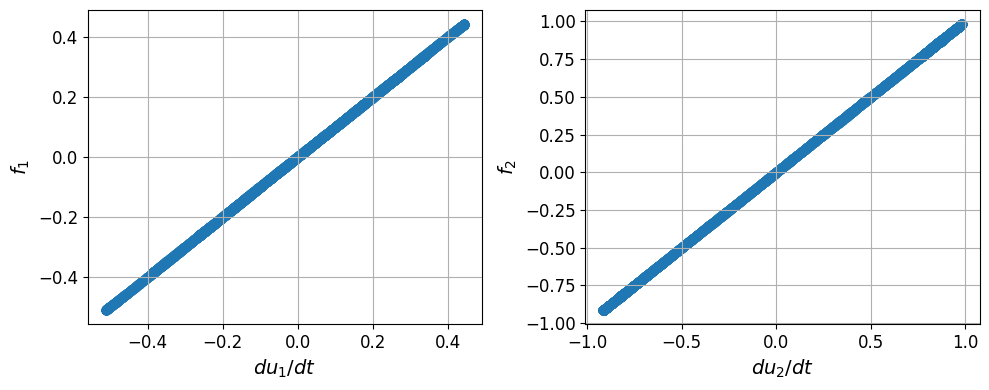

In [22]:
# Compare learned auxiliary terms against time derivatives
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_specs = [
    (axes[0], du1_dt.numpy().ravel(), f_pred[:, 0].numpy().ravel(), r"$du_1/dt$", r"$f_1$"),
    (axes[1], du2_dt.numpy().ravel(), f_pred[:, 1].numpy().ravel(), r"$du_2/dt$", r"$f_2$"),
]

for ax, x_values, y_values, x_label, y_label in plot_specs:
    ax.scatter(x_values, y_values)
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True)

plt.tight_layout()
plt.show()

# Symbolic Regression

In [23]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 31.7 MB/s eta 0:00:00


In [24]:
from pysr import PySRRegressor
import pandas as pd

# Load dataset
df = pd.read_csv('/content/f_NN_IO.csv')

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | 
           | [compat]
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
[juliapkg] Installing packages:
           | impo

In [25]:
df.head(10)

,t,u1,u2,u3,f1,f2
0,0.000000,1.000023,0.800372,0.499847,0.379636,0.475405
1,0.001000,1.000401,0.800839,0.498257,0.378760,0.474266
2,0.002000,1.000777,0.801305,0.496667,0.377881,0.473124
3,0.003000,1.001154,0.801772,0.495073,0.376998,0.471978
4,0.004000,1.001529,0.802236,0.493479,0.376111,0.470828
5,0.005000,1.001903,0.802700,0.491882,0.375221,0.469675
6,0.006001,1.002277,0.803163,0.490283,0.374326,0.468517
7,0.007001,1.002649,0.803625,0.488682,0.373427,0.467356
8,0.008001,1.003021,0.804087,0.487078,0.372525,0.466191
9,0.009001,1.003393,0.804547,0.485474,0.371619,0.465023


In [26]:
# Symbolic regression model
model = PySRRegressor(
    niterations=20,  # < Increase me for better results
    binary_operators=["+", "*"],
    unary_operators=[
        "cos",
        "exp",
        "sin",
        "inv(x) = 1/x",
    ],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
    loss="L1DistLoss()",
    model_selection="score",
    complexity_of_operators={
        "sin": 3, "cos": 3, "exp": 3,
        "inv(x) = 1/x": 3
    }
)

# NN for f1
X = df.iloc[:, :4].to_numpy()
f1 = df.loc[:, 'f1'].to_numpy()

model.fit(X, f1)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 2.840e+04
Progress: 143 / 620 total iterations (23.065%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.053e-01  0.000e+00  y = -0.032642
3           1.295e-01  2.305e-01  y = x₂ * x₃
5           5.450e-02  4.326e-01  y = (x₃ * 0.61313) * x₂
7           5.399e-02  4.620e-03  y = (x₃ * (x₂ * 0.61968)) + -0.0054549
9           5.394e-02  4.612e-04  y = (x₂ * ((x₃ + -0.0089719) * 0.62653)) + -0.0057341
20          5.394e-02  9.212e-08  y = ((((x₃ * -0.53843) + 0.005323) * x₂) * -0.97296) + sin...
                                      (((x₂ * x₃) + -0.05499) * 0.10177)
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                       -0.032641936   
	1         0.230498                                            x2 * x3   
	2         0.432623                              (x3 * 0.6131334) * x2   
	3         0.004620            (x3 * (x2 * 0.61968476)) + -0.005454853   
	4   >>>>  0.627870              x2 * (((x0 * x3) * -0.07611387) + x3)   
	5         0.074411  (((x0 * -0.033672955) + 0.47482595) * x3) * (x...   
	6         0.055403  (((x3 * (-0.081651054 * (x1 * x0))) + x3) * x2...   
	7         0.001115  (x2 * (((x0 * ((x1 * -0.0821619) * x3)) + x3) ...   
	8         0.011132  (x3 + ((x0 + -0.63647646) * ((x1 * -0.08591061...   
	9         0.012165  sin((x3 * 0.48528555) + (x3 * (x1 * (-0.040395...   
	10        0.022671  ((x2 + 0.0010969116) * ((x1 * 0.20710398) + 0....   
	11        0.005882  ((x2 + (x2 * 0.20738834)) * (((x3 * x3) * -0.0...   
	
	        loss  complexity  
	0   0.205276           1  
	1   0.129458           3  
	2   0.054495           5  
	3   0.053994           7  
	4   0.015381           9  
	5   0.013254          11  
	6   0.011864          13  
	7   0.011838          15  
	8   0.011577          17  
	9   0.011437          18  
	10  0.011181          19  
	11  0.010667          27  
]

  - outputs/20260319_210401_XcwMIu/hall_of_fame.csv


In [27]:
X = df.iloc[:, :4].to_numpy()
f2 = df.loc[:, 'f2'].to_numpy()

model.fit(X, f2)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.000e+04
Progress: 65 / 620 total iterations (10.484%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.590e-01  0.000e+00  y = -0.12167
3           1.142e-02  2.028e+00  y = x₃ * x₁
5           1.128e-02  6.176e-03  y = (x₁ * 0.99741) * x₃
10          1.063e-02  1.181e-02  y = (x₁ * x₃) * sin(x₁ + 0.80138)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.290e+04
Progress: 154 / 620 total iterations (24.839%)
════════════════════════════════════════════════════════════════════════════════════════════════════


[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        -0.12177416   
	1   >>>>  2.027582                                            x3 * x1   
	2         0.006176                              (x1 * 0.9974079) * x3   
	3         0.002983             x3 * ((0.97968644 * x1) + 0.013429582)   
	4         0.001479    x3 * (x1 + ((x2 + 0.45523265) * -0.0034944848))   
	5         0.050114                   (x3 * cos(x1 + -0.7693602)) * x1   
	6         0.009272            cos((x2 * 0.31922737) * x2) * (x1 * x3)   
	7         0.031032   x3 * (cos(x2 * ((x0 * -0.056707527) * x2)) * x1)   
	8         0.018329  x1 * (sin(cos(x3 * 0.76204884) + 0.87118846) *...   
	9         0.034399  (x1 * x3) * cos((((x2 * -0.08024868) * x0) * x...   
	10        0.007865  (x1 * x3) * cos((x0 * (x2 * ((x2 * 0.10502777)...   
	11        0.024339  (x1 * x3) * cos(((((((x2 * x2) * -1.2961998) +...   
	
	        loss  complexity  
	0   0.658979           1  
	1   0.011422           3  
	2   0.011282           5  
	3   0.011215           7  
	4   0.011181           9  
	5   0.010635          10  
	6   0.010439          12  
	7   0.009811          14  
	8   0.009633          15  
	9   0.009307          16  
	10  0.009162          18  
	11  0.008312          22  
]

  - outputs/20260319_210441_arQptK/hall_of_fame.csv
